# Lab 2.2 · Data Profiling ข้อมูลลูกค้า (customers.csv)

**ต่อจาก Lab 2.1 · 45 นาที**

ใน Lab 2.1 เราแก้ปัญหา "รูปแบบ" ของ `sales_raw.csv` ไปแล้ว (วันที่ พ.ศ., ชื่อสาขาสะกดต่าง, ราคามีคำว่า "บาท")
แต่ข้อมูลที่ **รูปแบบถูกทุกช่อง ก็ยังผิดได้** Lab นี้จะฝึกหาความผิดปกติ 3 ระดับ

| ระดับ | คำถาม | ตัวอย่าง |
|---|---|---|
| 1 · คอลัมน์ | แต่ละช่องถูกรูปแบบไหม | ค่าว่าง, รหัสซ้ำ, วันที่ผิดรูปแบบ |
| 2 · ข้ามตาราง | ตรงกับตารางอื่นไหม | สมัครก่อนสาขาเปิด, ลูกค้าในยอดขายที่ไม่มีในทะเบียน |
| 3 · ความหมาย | สมเหตุสมผลทางธุรกิจไหม | เบอร์โทรซ้ำ, เพศไม่สัมพันธ์กับชื่อ, ลูกค้าอายุต่ำกว่า 18 |

| ขั้น | เวลา | ทำอะไร |
|---|---|---|
| 1 | 5 นาที | โหลดและดูข้อมูลครั้งแรก |
| 2 | 10 นาที | Profiling ระดับคอลัมน์ |
| 3 | 10 นาที | Profiling ข้ามตาราง (customers × branches × sales) |
| 4 | 10 นาที | ความผิดปกติเชิงความหมาย |
| 5 | 5 นาที | ตัดสินใจว่าจะจัดการแต่ละเรื่องอย่างไร |
| 6 | 5 นาที | Export รายงาน profiling และไฟล์ที่ติด flag |

**หลักสำคัญของ Lab นี้:** รายงานและติด flag เท่านั้น **ไม่ลบ ไม่แก้** ข้อมูลลูกค้า เพราะทะเบียนลูกค้าเป็นข้อมูลต้นทางที่ฝ่ายอื่นใช้ต่อ

**วิธีใช้กับ AI:** ใช้ Gemini ใน Colab หรือคัดลอก prompt ไปใช้กับ Claude / ChatGPT แล้ววางโค้ดกลับมา (ในเซลล์มีโค้ดตัวอย่างให้แล้ว ลองเขียน prompt เองก่อนแล้วเทียบผล)

## ขั้นที่ 0 · เตรียมเครื่องมือ
รันเซลล์นี้ก่อน (ไม่ต้องแก้) มีฟังก์ชัน `check()` สำหรับตรวจคำตอบโดยไม่เฉลยตัวเลข และ `load_csv()` สำหรับอัปโหลดไฟล์ใน Colab

In [1]:
# ===== เซลล์ตัวช่วยของ Lab 2.2 · รันก่อน ไม่ต้องแก้ =====
import base64, json, os, re
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

_EXP = json.loads(base64.b64decode(
    "eyJyYXdfcm93cyI6IDMwMDAsICJkdXBfaWQiOiAwLCAiYmxhbmtfY2VsbHMiOiAwLCAiYmFkX2RhdGUiOiAwLCAiYmFkX3Bob25lIjogMCwgInVua25vd25fYnJhbmNoIjogMCwgImR1cF9waG9uZV9yb3dzIjogOTksICJqb2luZWRfYmVmb3JlX29wZW4iOiAwLCAib3JwaGFuX3NhbGVzX2lkcyI6IDAsICJuZXZlcl9ib3VnaHQiOiA0OTMsICJtaW5vcnMiOiAxMTN9"
).decode())
_LABEL = {
    "raw_rows": "จำนวนลูกค้าทั้งหมด",
    "dup_id": "customer_id ที่ซ้ำ (ไม่นับตัวแรก)",
    "blank_cells": "จำนวนช่องว่างทั้งไฟล์",
    "bad_date": "joined_date ที่ไม่ใช่ YYYY-MM-DD หรือเป็นวันที่ที่ไม่มีจริง",
    "bad_phone": "phone ที่ไม่ใช่รูปแบบ 0XX-xxx-XXXX",
    "unknown_branch": "home_branch_id ที่ไม่มีใน branches.csv",
    "dup_phone_rows": "แถวที่ใช้เบอร์โทรซ้ำกับคนอื่น (นับทุกแถวในกลุ่ม)",
    "joined_before_open": "ลูกค้าที่สมัครก่อนสาขาของตัวเองเปิด",
    "orphan_sales_ids": "customer_id ใน sales ที่ไม่มีใน customers (นับรหัสไม่ซ้ำ)",
    "never_bought": "ลูกค้าที่ไม่เคยซื้อเลยใน sales",
    "minors": "ลูกค้าอายุต่ำกว่า 18",
}
_HINT = {
    "dup_id": "ใช้ df['customer_id'].duplicated().sum()",
    "blank_cells": "อ่านไฟล์ด้วย keep_default_na=False ค่าว่างจึงเป็น '' ลอง (df.apply(lambda s: s.str.strip()) == '').sum().sum()",
    "bad_date": "pd.to_datetime(..., format='%Y-%m-%d', errors='coerce').isna() จับทั้งรูปแบบผิดและวันที่ที่ไม่มีจริง",
    "bad_phone": "regex r'^0\\d{2}-xxx-\\d{4}$'",
    "dup_phone_rows": "ใช้ duplicated(keep=False) เพื่อนับทุกแถวในกลุ่ม ไม่ใช่แค่ตัวที่สอง",
    "joined_before_open": "merge กับ branches.csv ด้วย home_branch_id = branch_id แล้วเทียบ joined_date < opened_date",
    "orphan_sales_ids": "ตัดแถว customer_id ว่างใน sales ออกก่อน แล้วนับ set ที่ไม่อยู่ใน customers",
    "never_bought": "ลูกค้าใน customers ที่ไม่อยู่ใน sales['customer_id'].unique()",
    "minors": "age_group == 'ต่ำกว่า 18'",
}


def check(name, value):
    """เทียบคำตอบกับเฉลยโดยไม่บอกตัวเลข"""
    exp = _EXP[name]
    label = _LABEL[name]
    if value is None:
        print(f"⬜ {label}: ยังไม่ได้ใส่ค่า")
    elif int(value) == exp:
        print(f"✅ {label}: {int(value):,}")
    elif abs(int(value) - exp) <= max(2, exp * 0.03):
        print(f"🟡 {label}: {int(value):,} ใกล้แล้ว แต่ยังไม่ตรง · {_HINT.get(name, 'ตรวจเงื่อนไขอีกครั้ง')}")
    else:
        print(f"❌ {label}: {int(value):,} ยังไม่ถูก · {_HINT.get(name, 'ตรวจเงื่อนไขอีกครั้ง')}")


def load_csv(name):
    """อ่าน CSV ทุกคอลัมน์เป็นข้อความ ถ้าไม่มีไฟล์จะให้อัปโหลด (Google Colab)"""
    if not os.path.exists(name):
        try:
            from google.colab import files
            print(f"ไม่พบ {name} กรุณาอัปโหลดไฟล์")
            files.upload()
        except ImportError:
            raise FileNotFoundError(f"ไม่พบไฟล์ {name} ให้วางไฟล์ไว้โฟลเดอร์เดียวกับ notebook")
    return pd.read_csv(name, dtype=str, keep_default_na=False, encoding="utf-8-sig")


AGE_ORDER = ["ต่ำกว่า 18", "18-24", "25-34", "35-44", "45-54", "55+"]
STD_GENDER = ["ชาย", "หญิง", "ไม่ระบุ"]
print("พร้อมแล้ว")

พร้อมแล้ว


## ขั้นที่ 1 · ดูข้อมูลครั้งแรก (5 นาที)

อัปโหลด 3 ไฟล์ (ใน Colab จะมีปุ่มให้อัปโหลดทีละไฟล์)
- `customers.csv` · ทะเบียนสมาชิก ไฟล์หลักของ Lab นี้
- `branches.csv` · ข้อมูลสาขาและวันเปิด
- `sales.csv` · ยอดขายที่ทำความสะอาดแล้วจาก Lab 2.1 (`sales_clean.csv` ที่เปลี่ยนชื่อแล้ว หรือไฟล์ใน `public/` ของ Dashboard)

อ่าน **ทุกคอลัมน์เป็นข้อความ** เหมือน Lab 2.1 เพื่อไม่ให้ pandas ซ่อนปัญหา

In [2]:
cust = load_csv("customers.csv")
branches = load_csv("branches.csv")
sales = load_csv("sales.csv")

print(f"customers: {len(cust):,} แถว × {cust.shape[1]} คอลัมน์")
print(f"branches : {len(branches):,} แถว · sales: {len(sales):,} แถว")
cust.head(8)

customers: 3,000 แถว × 7 คอลัมน์
branches : 5 แถว · sales: 53,057 แถว


,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone
0,C00001,กมล,หญิง,18-24,B02,2026-03-03,082-xxx-6693
1,C00002,กิตติ,ชาย,25-34,B04,2026-01-18,084-xxx-3734
2,C00003,ปิยะ,หญิง,18-24,B04,2025-05-04,089-xxx-9286
3,C00004,ปิยะ,หญิง,18-24,B05,2026-05-05,083-xxx-7314
4,C00005,รัตนา,หญิง,25-34,B04,2026-07-10,083-xxx-5701
5,C00006,กมล,ชาย,18-24,B04,2026-08-16,086-xxx-1895
6,C00007,วรรณ,ชาย,45-54,B03,2026-07-17,087-xxx-3147
7,C00008,ภัทร,หญิง,25-34,B01,2026-04-07,087-xxx-9877


**คำถามชวนคิด:** คอลัมน์ไหนในไฟล์นี้เป็น **ข้อมูลส่วนบุคคล** ตาม PDPA บ้าง และทำไมเบอร์โทรถึงถูกปิดเลขกลางเป็น `xxx`

## ขั้นที่ 2 · Profiling ระดับคอลัมน์ (10 นาที)

**Prompt**
```
ช่วยทำ data profiling ของ DataFrame cust ด้วย pandas (ทุกคอลัมน์เป็น str ค่าว่างเป็น "")
คอลัมน์: customer_id, nickname, gender, age_group, home_branch_id, joined_date, phone
- จำนวนค่าว่าง ค่าไม่ซ้ำ และค่าที่มีช่องว่างหน้า/ท้าย ของแต่ละคอลัมน์
- customer_id ซ้ำไหม รูปแบบ C + เลข 5 หลักครบทุกแถวไหม และเลขรันต่อเนื่องหรือมีเลขหาย
- ค่าทั้งหมดของ gender, age_group, home_branch_id พร้อมจำนวน
- joined_date ที่ไม่ใช่ YYYY-MM-DD หรือเป็นวันที่ไม่มีจริง พร้อมช่วงวันที่ต่ำสุด–สูงสุด
- phone ที่ไม่ใช่รูปแบบ 0XX-xxx-XXXX
เก็บจำนวนไว้ในตัวแปร n_dup_id, n_blank, n_bad_date, n_bad_phone
อย่าแก้ข้อมูล ให้รายงานอย่างเดียว
```

In [3]:
import pandas as pd

print(f"ขนาดข้อมูล: {len(cust):,} แถว × {cust.shape[1]} คอลัมน์\n")

# 1) ค่าว่าง / ค่าไม่ซ้ำ / ช่องว่างหน้า-ท้าย ของแต่ละคอลัมน์
stripped = cust.apply(lambda s: s.str.strip())
summary = pd.DataFrame({
    "ค่าว่าง": (stripped == "").sum(),          # นับ " " เป็นค่าว่างด้วย
    "ค่าไม่ซ้ำ": cust.nunique(),
    "มีช่องว่างหน้า/ท้าย": (cust != stripped).sum(),
})
n_blank = int(summary["ค่าว่าง"].sum())
print("== 1) ภาพรวมคอลัมน์ ==\n", summary, "\n")

# 2) customer_id: ซ้ำ / รูปแบบ C+5 หลัก / เลขรันต่อเนื่อง
ids = cust["customer_id"]
n_dup_id = int(ids.duplicated().sum())
bad_id = ~ids.str.match(r"^C\d{5}$")
nums = ids[~bad_id].str[1:].astype(int)
missing_ids = sorted(set(range(nums.min(), nums.max() + 1)) - set(nums))
print("== 2) customer_id ==")
print(f"ซ้ำ: {n_dup_id:,} · รูปแบบผิด: {bad_id.sum():,} {ids[bad_id].head(5).tolist()}")
print(f"ช่วง: C{nums.min():05d}–C{nums.max():05d} · เลขที่หาย: {len(missing_ids):,} "
      f"{['C%05d' % x for x in missing_ids[:10]]}\n")

# 3) ค่าทั้งหมดของคอลัมน์หมวดหมู่ (repr ช่วยให้เห็นช่องว่างที่ซ่อนอยู่)
for col in ["gender", "age_group", "home_branch_id"]:
    vc = cust[col].value_counts()
    vc.index = [repr(x) for x in vc.index]
    print(f"== 3) {col} ({len(vc)} ค่า) ==\n{vc.to_string()}\n")

# 4) joined_date: ต้องเป็น YYYY-MM-DD และเป็นวันที่มีจริง
jd = pd.to_datetime(cust["joined_date"], format="%Y-%m-%d", errors="coerce")
bad_date = jd.isna() | ~cust["joined_date"].str.match(r"^\d{4}-\d{2}-\d{2}$")
n_bad_date = int(bad_date.sum())
print(f"== 4) joined_date ผิดรูปแบบ/ไม่มีจริง: {n_bad_date:,} "
      f"ตัวอย่าง {cust.loc[bad_date, 'joined_date'].head(5).tolist()}")
print(f"ช่วงวันที่: {jd.min():%Y-%m-%d} ถึง {jd.max():%Y-%m-%d}\n")

# 5) phone: 0XX-xxx-XXXX
bad_phone = ~cust["phone"].str.match(r"^0\d{2}-xxx-\d{4}$")
n_bad_phone = int(bad_phone.sum())
print(f"== 5) phone ผิดรูปแบบ: {n_bad_phone:,} ตัวอย่าง {cust.loc[bad_phone, 'phone'].head(5).tolist()}\n")

print(dict(n_dup_id=n_dup_id, n_blank=n_blank, n_bad_date=n_bad_date, n_bad_phone=n_bad_phone))

ขนาดข้อมูล: 3,000 แถว × 7 คอลัมน์

== 1) ภาพรวมคอลัมน์ ==
                 ค่าว่าง  ค่าไม่ซ้ำ  มีช่องว่างหน้า/ท้าย
customer_id           0       3000                    0
nickname              0         24                    0
gender                0          3                    0
age_group             0          6                    0
home_branch_id        0          5                    0
joined_date           0        530                    0
phone                 0       2950                    0 

== 2) customer_id ==
ซ้ำ: 0 · รูปแบบผิด: 0 []
ช่วง: C00001–C03000 · เลขที่หาย: 0 []

== 3) gender (3 ค่า) ==
'หญิง'       1652
'ชาย'        1232
'ไม่ระบุ'     116

== 3) age_group (6 ค่า) ==
'25-34'         993
'18-24'         775
'35-44'         577
'45-54'         346
'55+'           196
'ต่ำกว่า 18'    113

== 3) home_branch_id (5 ค่า) ==
'B01'    776
'B05'    693
'B02'    643
'B04'    483
'B03'    405

== 4) joined_date ผิดรูปแบบ/ไม่มีจริง: 0 ตัวอย่าง []
ช่วงวันที่: 2025-04-01 ถึง 2

### ✔️ ตรวจคำตอบระดับคอลัมน์

**คำถามชวนคิด:** ถ้าได้ ✅ ทุกข้อและทุกค่าเป็น 0 แปลว่าข้อมูล "สะอาด" แล้วหรือยัง

In [4]:
check("raw_rows", len(cust))
check("dup_id", n_dup_id)
check("blank_cells", n_blank)
check("bad_date", n_bad_date)
check("bad_phone", n_bad_phone)

✅ จำนวนลูกค้าทั้งหมด: 3,000
✅ customer_id ที่ซ้ำ (ไม่นับตัวแรก): 0
✅ จำนวนช่องว่างทั้งไฟล์: 0
✅ joined_date ที่ไม่ใช่ YYYY-MM-DD หรือเป็นวันที่ที่ไม่มีจริง: 0
✅ phone ที่ไม่ใช่รูปแบบ 0XX-xxx-XXXX: 0


## ขั้นที่ 3 · Profiling ข้ามตาราง (10 นาที)

ข้อมูลที่รูปแบบถูกอาจ **ขัดกับตารางอื่น** ได้ ตรวจความสอดคล้องระหว่าง `customers`, `branches` และ `sales`

**Prompt**
```
มี DataFrame 3 ตัว (ทุกคอลัมน์เป็น str ค่าว่างเป็น "")
- cust: customer_id, nickname, gender, age_group, home_branch_id, joined_date (YYYY-MM-DD), phone
- branches: branch_id, branch (ชื่อสาขา), branch_type, lat, lng, opened_date
- sales: order_id, datetime (YYYY-MM-DDTHH:MM:SS+07:00), branch (ชื่อสาขา), product_id, qty, unit_price, customer_id (ว่าง = ลูกค้าทั่วไป), ...
ช่วยตรวจ (รายงานอย่างเดียว ห้ามแก้ข้อมูล)
1. home_branch_id ที่ไม่มีใน branches
2. ลูกค้าที่ joined_date ก่อน opened_date ของสาขาตัวเอง
3. customer_id ใน sales ที่ไม่มีใน cust (นับรหัสไม่ซ้ำ)
4. ลูกค้าที่ไม่เคยซื้อเลย
5. ลูกค้าที่ซื้อครั้งแรกก่อนวันสมัคร (ใช้ 10 ตัวอักษรแรกของ datetime เป็นวันที่ ห้ามใช้ pd.to_datetime เพราะจะแปลงเป็น UTC)
6. สัดส่วนลูกค้าที่ home_branch ตรงกับสาขาที่ซื้อบ่อยที่สุด
7. วันสมัครเร็วสุดของแต่ละสาขา เทียบกับวันเปิดสาขา และวันแรกของ sales
เก็บจำนวนไว้ในตัวแปร n_unknown_branch, n_joined_before_open, n_orphan_ids, n_never_bought, n_buy_before_join
```

In [5]:
import pandas as pd

br = branches.set_index("branch_id")
name_to_id = dict(zip(branches["branch"], branches["branch_id"]))

# 1) home_branch_id ที่ไม่มีใน branches
unknown = ~cust["home_branch_id"].isin(br.index)
n_unknown_branch = int(unknown.sum())
print(f"1) home_branch_id ที่ไม่มีใน branches: {n_unknown_branch:,} "
      f"{cust.loc[unknown, 'home_branch_id'].unique().tolist()}")

# 2) สมัครก่อนสาขาตัวเองเปิด (สตริง YYYY-MM-DD เทียบกันตรง ๆ ได้)
opened = cust["home_branch_id"].map(br["opened_date"])
n_joined_before_open = int((opened.notna() & (cust["joined_date"] < opened)).sum())
print(f"2) สมัครก่อนสาขาเปิด: {n_joined_before_open:,}")

# เตรียม sales: เฉพาะสมาชิก + วันที่จาก 10 ตัวอักษรแรก (เวลาไทยตามที่บันทึก ไม่เลื่อนเป็น UTC)
s = sales[sales["customer_id"].str.strip() != ""].copy()
s["date"] = s["datetime"].str[:10]

# 3) customer_id ใน sales ที่ไม่มีในทะเบียน (นับรหัสไม่ซ้ำ)
ids_cust, ids_sales = set(cust["customer_id"]), set(s["customer_id"])
orphan = ids_sales - ids_cust
n_orphan_ids = len(orphan)
print(f"3) customer_id ใน sales ที่ไม่มีใน cust: {n_orphan_ids:,} {sorted(orphan)[:10]}")

# 4) ลูกค้าที่ไม่เคยซื้อ
n_never_bought = int((~cust["customer_id"].isin(ids_sales)).sum())
print(f"4) ลูกค้าที่ไม่เคยซื้อ: {n_never_bought:,} ({n_never_bought / len(cust):.1%})")

# 5) ซื้อครั้งแรกก่อนวันสมัคร
first_buy = s.groupby("customer_id")["date"].min().rename("first_buy")
j = cust.set_index("customer_id").join(first_buy, how="inner")
n_buy_before_join = int((j["first_buy"] < j["joined_date"]).sum())
gap = (pd.to_datetime(j["first_buy"]) - pd.to_datetime(j["joined_date"])).dt.days  # วันที่ล้วน ไม่มี timezone
print(f"5) ซื้อครั้งแรกก่อนวันสมัคร: {n_buy_before_join:,} · "
      f"จากสมัครถึงซื้อครั้งแรก: ค่ากลาง {gap.median():.0f} วัน")

# 6) home_branch ตรงกับสาขาที่ซื้อบ่อยที่สุดไหม (เฉพาะคนที่เคยซื้อ)
#    นับเป็น "บิล" ต่อสาขา (1 บิลมีหลายแถว) และถ้าสาขาตัวเองเสมอกับสาขาอื่น ถือว่ายังตรง
s["branch_id"] = s["branch"].map(name_to_id)
print(f"   (ชื่อสาขาใน sales ที่ map ไม่ได้: {s['branch_id'].isna().sum():,})")
bills = s.groupby(["customer_id", "branch_id"])["order_id"].nunique().unstack(fill_value=0)
hb = cust.set_index("customer_id")["home_branch_id"].reindex(bills.index)
home_bills = pd.Series([bills.at[c, h] if h in bills.columns else 0 for c, h in hb.items()], index=bills.index)
match = home_bills >= bills.max(axis=1)      # True = ซื้อสาขาตัวเองบ่อยที่สุด (หรือเท่ากับสาขาอื่น)
print(f"6) ซื้อสาขาตัวเองบ่อยที่สุด (หรือเท่ากัน): {match.mean():.1%} "
      f"(ซื้อสาขาอื่นบ่อยกว่า {(~match).sum():,} คน · ในนี้ไม่เคยซื้อสาขาตัวเองเลย "
      f"{((~match) & (home_bills == 0)).sum():,} คน)")

# 7) วันสมัครเร็วสุดของแต่ละสาขา เทียบวันเปิดสาขาและวันแรกของ sales
sales_first = sales["datetime"].str[:10].min()
first_join = cust.groupby("home_branch_id")["joined_date"].agg(สมัครเร็วสุด="min", สมัครล่าสุด="max", สมาชิก="count")
first_join.insert(0, "สาขา", br["branch"])
first_join["วันเปิดสาขา"] = br["opened_date"]
first_join["สมัครวันเดียวกับ sales วันแรก"] = first_join["สมัครเร็วสุด"] == sales_first
print(f"\n7) sales: {sales_first} ถึง {sales['datetime'].str[:10].max()}")
display(first_join)

print(dict(n_unknown_branch=n_unknown_branch, n_joined_before_open=n_joined_before_open,
           n_orphan_ids=n_orphan_ids, n_never_bought=n_never_bought, n_buy_before_join=n_buy_before_join))

1) home_branch_id ที่ไม่มีใน branches: 0 []
2) สมัครก่อนสาขาเปิด: 0
3) customer_id ใน sales ที่ไม่มีใน cust: 0 []
4) ลูกค้าที่ไม่เคยซื้อ: 493 (16.4%)
5) ซื้อครั้งแรกก่อนวันสมัคร: 0 · จากสมัครถึงซื้อครั้งแรก: ค่ากลาง 17 วัน
   (ชื่อสาขาใน sales ที่ map ไม่ได้: 0)
6) ซื้อสาขาตัวเองบ่อยที่สุด (หรือเท่ากัน): 97.4% (ซื้อสาขาอื่นบ่อยกว่า 64 คน · ในนี้ไม่เคยซื้อสาขาตัวเองเลย 60 คน)

7) sales: 2025-04-01 ถึง 2026-09-20


,สาขา,สมัครเร็วสุด,สมัครล่าสุด,สมาชิก,วันเปิดสาขา,สมัครวันเดียวกับ sales วันแรก
home_branch_id,,,,,,
B01,สยาม,2025-04-01,2026-09-14,776,2023-06-01,True
B02,สีลม,2025-04-01,2026-09-14,643,2023-09-15,True
B03,อารีย์,2025-11-01,2026-09-13,405,2025-11-01,False
B04,บางนา,2025-04-03,2026-09-14,483,2024-03-01,False
B05,มหาวิทยาลัย,2025-04-01,2026-09-13,693,2024-06-01,True


{'n_unknown_branch': 0, 'n_joined_before_open': 0, 'n_orphan_ids': 0, 'n_never_bought': 493, 'n_buy_before_join': 0}


### ✔️ ตรวจคำตอบข้ามตาราง

In [6]:
check("unknown_branch", n_unknown_branch)
check("joined_before_open", n_joined_before_open)
check("orphan_sales_ids", n_orphan_ids)
check("never_bought", n_never_bought)

✅ home_branch_id ที่ไม่มีใน branches.csv: 0
✅ ลูกค้าที่สมัครก่อนสาขาของตัวเองเปิด: 0
✅ customer_id ใน sales ที่ไม่มีใน customers (นับรหัสไม่ซ้ำ): 0
✅ ลูกค้าที่ไม่เคยซื้อเลยใน sales: 493


**คำถามชวนคิด (ดูตารางข้อ 7):** สาขาสยามเปิดตั้งแต่ปี 2023 แต่ทำไม **ไม่มีสมาชิกคนไหนสมัครก่อน 2025-04-01** เลย
เป็นไปได้กี่สาเหตุ และควรถามใครก่อนจะสรุปว่า "สมาชิกใหม่ปีแรกโตเร็ว"

## ขั้นที่ 4 · ความผิดปกติเชิงความหมาย (10 นาที)

ส่วนนี้โค้ดหาตัวเลขได้ แต่ **คนต้องตีความ** ว่าผิดปกติจริงหรือเป็นเรื่องที่คาดได้

### 4.1 เบอร์โทรซ้ำ = ลูกค้าซ้ำหรือเปล่า

**Prompt**
```
ใน cust ให้หาแถวที่ phone ซ้ำกับคนอื่น (นับทุกแถวในกลุ่ม) แสดงตัวอย่างกลุ่มที่ซ้ำ
และบอกว่าในแต่ละกลุ่ม nickname / gender / age_group / home_branch_id เหมือนกันกี่กลุ่ม
เบอร์ถูกปิดเลขกลางเป็น xxx เหลือ prefix 3 หลัก + เลขท้าย 4 หลัก
ช่วยคำนวณด้วยว่าถ้าเบอร์สุ่มจริง ๆ จะคาดว่ามีแถวที่ชนกันกี่แถว (birthday problem)
เก็บจำนวนแถวที่ซ้ำไว้ใน n_dup_phone_rows
```

In [7]:
import numpy as np
import pandas as pd

ATTRS = ["nickname", "gender", "age_group", "home_branch_id"]

# 1) แถวที่ phone ซ้ำกับคนอื่น (keep=False = นับทุกแถวในกลุ่ม ไม่ใช่แค่ตัวที่สอง)
dup_mask = cust["phone"].duplicated(keep=False)
n_dup_phone_rows = int(dup_mask.sum())
dups = cust[dup_mask].sort_values(["phone", "customer_id"])
groups = dups.groupby("phone")
size_dist = groups.size().value_counts().sort_index()
print(f"แถวที่ phone ซ้ำ: {n_dup_phone_rows:,} แถว ใน {groups.ngroups:,} กลุ่ม "
      f"({' · '.join(f'{k} คน/กลุ่ม: {v}' for k, v in size_dist.items())})\n")

# 2) ตัวอย่างกลุ่มที่ซ้ำ (กลุ่มใหญ่สุดก่อน)
order = groups.size().sort_values(ascending=False).index[:5]
display(dups.set_index("phone").loc[order].reset_index())

# 3) ในแต่ละกลุ่ม แต่ละคอลัมน์มีค่าเดียวกันทั้งกลุ่มไหม
same = groups[ATTRS].nunique().eq(1)
same["ทุกคอลัมน์เหมือน"] = same[ATTRS].all(axis=1)
print("จำนวนกลุ่มที่ค่าเหมือนกันทั้งกลุ่ม:")
print(same.sum().astype(int).to_string())

# 4) ถ้าเบอร์สุ่มจริง จะคาดว่าชนกันกี่แถว (birthday problem)
#    เบอร์ที่เป็นไปได้ N = จำนวน prefix × 10,000 (เลขท้าย 4 หลัก)
#    P(แถวหนึ่งชนกับอย่างน้อย 1 แถว) = 1 − (1 − 1/N)^(n−1) → คูณ n = จำนวนแถวที่คาดว่าชน
n = len(cust)
N = cust["phone"].str[:3].nunique() * 10_000
expected = n * (1 - (1 - 1 / N) ** (n - 1))
exp_pairs = n * (n - 1) / 2 / N
print(f"\nn = {n:,} คน · N = {N:,} เบอร์ที่เป็นไปได้")
print(f"ถ้าสุ่ม: คาดว่าชนกัน ≈ {expected:.1f} แถว (≈ {exp_pairs:.1f} คู่) · พบจริง {n_dup_phone_rows:,} แถว")

# 5) ช่วงที่เป็นไปได้จากความบังเอิญ (จำลองสุ่ม 2,000 รอบ)
rng = np.random.default_rng(0)
sim = [pd.Series(rng.integers(0, N, n)).duplicated(keep=False).sum() for _ in range(2000)]
lo, hi = np.percentile(sim, [2.5, 97.5])
verdict = "อยู่ในช่วงที่เกิดจากความบังเอิญได้" if lo <= n_dup_phone_rows <= hi else "อยู่นอกช่วง ควรตรวจเพิ่ม"
print(f"จำลองสุ่ม 2,000 รอบ: 95% อยู่ระหว่าง {lo:.0f}–{hi:.0f} แถว → ค่าที่พบ{verdict}")

แถวที่ phone ซ้ำ: 99 แถว ใน 49 กลุ่ม (2 คน/กลุ่ม: 48 · 3 คน/กลุ่ม: 1)



,phone,customer_id,nickname,gender,age_group,home_branch_id,joined_date
0,083-xxx-5083,C00972,เกศ,ชาย,25-34,B04,2026-02-14
1,083-xxx-5083,C01482,กมล,หญิง,25-34,B05,2025-09-20
2,083-xxx-5083,C02487,อัญชลี,หญิง,45-54,B02,2026-09-04
3,081-xxx-4308,C02207,ทิพย์,ชาย,35-44,B02,2025-04-14
4,081-xxx-4308,C02248,อัญชลี,ชาย,35-44,B02,2026-03-15
5,081-xxx-5843,C02179,อัญชลี,หญิง,25-34,B01,2025-06-24
6,081-xxx-5843,C02843,ธีร,หญิง,25-34,B05,2026-05-20
7,081-xxx-8023,C00133,มานพ,ชาย,35-44,B02,2025-06-08
8,081-xxx-8023,C01635,ธีร,หญิง,18-24,B01,2026-04-28
9,081-xxx-6451,C00884,ภัทร,ชาย,45-54,B01,2025-09-07


จำนวนกลุ่มที่ค่าเหมือนกันทั้งกลุ่ม:
nickname             1
gender              26
age_group           19
home_branch_id      10
ทุกคอลัมน์เหมือน     0

n = 3,000 คน · N = 90,000 เบอร์ที่เป็นไปได้
ถ้าสุ่ม: คาดว่าชนกัน ≈ 98.3 แถว (≈ 50.0 คู่) · พบจริง 99 แถว
จำลองสุ่ม 2,000 รอบ: 95% อยู่ระหว่าง 70–126 แถว → ค่าที่พบอยู่ในช่วงที่เกิดจากความบังเอิญได้


In [8]:
check("dup_phone_rows", n_dup_phone_rows)

✅ แถวที่ใช้เบอร์โทรซ้ำกับคนอื่น (นับทุกแถวในกลุ่ม): 99


**คำถามชวนคิด:** จำนวนที่ซ้ำจริงใกล้กับค่าที่คาดจากการสุ่มแค่ไหน ถ้าใกล้กัน แปลว่าอะไร
แล้วถ้าทีมการตลาดอยาก "รวมบัญชีลูกค้าที่เบอร์เดียวกัน" ควรตอบเขาว่าอะไร

### 4.2 เพศสัมพันธ์กับชื่อเล่นไหม

ชื่ออย่าง "สมชาย" หรือ "อัญชลี" บอกเพศได้ค่อนข้างชัด ถ้าข้อมูลถูกต้อง ชื่อเหล่านี้ควรเป็นเพศเดียวเกือบทั้งหมด

In [9]:
ct = pd.crosstab(cust["nickname"], cust["gender"])[STD_GENDER]
ct["%หญิง"] = (ct["หญิง"] / ct[["ชาย", "หญิง"]].sum(axis=1) * 100).round(1)
ct = ct.sort_values("%หญิง")
print(f"%หญิง ต่อชื่อ: ต่ำสุด {ct['%หญิง'].min()}% · สูงสุด {ct['%หญิง'].max()}% · ภาพรวม "
      f"{(cust['gender'] == 'หญิง').sum() / cust['gender'].isin(['ชาย', 'หญิง']).sum():.1%}")
ct.loc[[x for x in ["สมชาย", "มานพ", "วีระ", "กิตติ", "อัญชลี", "สุดา", "รัตนา", "พิม"] if x in ct.index]]

%หญิง ต่อชื่อ: ต่ำสุด 48.4% · สูงสุด 67.8% · ภาพรวม 57.3%


gender,ชาย,หญิง,ไม่ระบุ,%หญิง
nickname,,,,
สมชาย,50,59,7,54.1
มานพ,48,64,10,57.1
วีระ,48,53,3,52.5
กิตติ,49,71,4,59.2
อัญชลี,62,79,7,56.0
สุดา,39,82,6,67.8
รัตนา,57,80,3,58.4
พิม,39,77,10,66.4


**คำถามชวนคิด:** ถ้าทุกชื่อมี %หญิง ใกล้ค่าภาพรวม แปลว่าคอลัมน์ไหน (gender หรือ nickname) เชื่อถือไม่ได้
ควรใช้ gender วิเคราะห์ "เมนูที่ผู้หญิงชอบ" ต่อหรือไม่

### 4.3 อายุ และการสมัครรายเดือน

ลูกค้าอายุต่ำกว่า 18: 113 คน (3.8%)


,B01 ห้าง,B02 ออฟฟิศ,B03 ชุมชน,B04 ห้าง,B05 สถานศึกษา
age_group,,,,,
ต่ำกว่า 18,3.0,2.8,3.5,5.6,4.5
18-24,25.4,24.4,28.4,28.0,24.7
25-34,34.1,32.3,29.4,33.5,34.5
35-44,20.2,21.6,23.7,13.9,17.0
45-54,11.1,13.4,9.9,11.2,11.5
55+,6.2,5.4,5.2,7.9,7.8


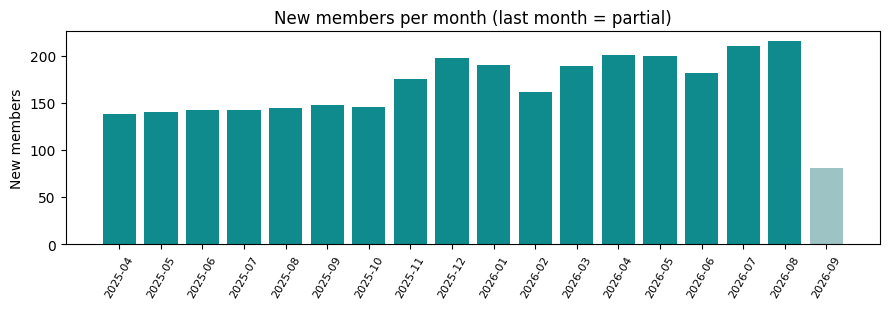

เดือนสุดท้าย 2026-09 มีสมาชิกใหม่ 81 คน ข้อมูลถึงวันที่ 2026-09-14


In [10]:
n_minors = int((cust["age_group"] == "ต่ำกว่า 18").sum())
print(f"ลูกค้าอายุต่ำกว่า 18: {n_minors:,} คน ({n_minors / len(cust):.1%})")

age_branch = pd.crosstab(cust["age_group"], cust["home_branch_id"], normalize="columns").reindex(AGE_ORDER)
age_branch.columns = [f"{c} {br.loc[c, 'branch_type']}" for c in age_branch.columns]
display((age_branch * 100).round(1))

monthly = cust["joined_date"].str[:7].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(monthly.index, monthly.values, color=["#9DC3C4" if m == monthly.index[-1] else "#0F8B8D" for m in monthly.index])
ax.set_ylabel("New members"); ax.set_title("New members per month (last month = partial)")
ax.tick_params(axis="x", rotation=60, labelsize=8)
plt.tight_layout(); plt.show()
# หมายเหตุ: ใช้ป้ายภาษาอังกฤษ เพราะ matplotlib ใน Colab ไม่มีฟอนต์ไทย
print(f"เดือนสุดท้าย {monthly.index[-1]} มีสมาชิกใหม่ {monthly.iloc[-1]:,} คน ข้อมูลถึงวันที่ {cust['joined_date'].max()}")

In [11]:
check("minors", n_minors)

✅ ลูกค้าอายุต่ำกว่า 18: 113


**คำถามชวนคิด:**
- สาขามหาวิทยาลัย (สถานศึกษา) ควรมีลูกค้าอายุ 18-24 มากกว่าสาขาอื่นชัดเจน ข้อมูลเป็นอย่างนั้นไหม
- ลูกค้าอายุต่ำกว่า 18 ที่มีเบอร์โทรในระบบ ต้องระวังอะไรตาม PDPA ก่อนส่ง SMS โปรโมชัน

## ขั้นที่ 5 · ตัดสินใจก่อนลงมือ (5 นาที · คุยกับเพื่อนข้าง ๆ)

ดับเบิลคลิกเซลล์นี้เพื่อกรอกตาราง

| สิ่งที่พบ | ทางเลือก | ตัดสินใจ | เหตุผล |
|---|---|---|---|
| เบอร์โทรซ้ำ | รวมบัญชี / ติด flag / ไม่ทำอะไร | | |
| เพศไม่สัมพันธ์กับชื่อ | ใช้ต่อ / ใช้แบบมีข้อจำกัด / ไม่ใช้ | | |
| สมาชิกเริ่ม 2025-04-01 ทุกสาขา | ถามเจ้าของข้อมูล / สรุปว่าโปรแกรมเพิ่งเริ่ม | | |
| สมาชิกที่ไม่เคยซื้อ | ลบ / เก็บ + ติด flag สำหรับแคมเปญ | | |
| home_branch ≠ สาขาที่ซื้อจริง | ใช้ home_branch / ใช้สาขาที่ซื้อจริง | | |
| ลูกค้าอายุต่ำกว่า 18 | ติด flag ห้ามส่งการตลาด / ไม่ทำอะไร | | |

> **สำหรับผู้สอน:** เติมข้อมูลจากร้านตรงนี้ก่อนแจกนักศึกษา เช่น เบอร์โทรถูกปิดเลขกลางตั้งแต่ตอน export หรือไม่ ·
> โปรแกรมสมาชิกเริ่มเมื่อไร หรือมีการย้ายระบบที่ทำให้ joined_date ของสมาชิกเก่าเปลี่ยนไปหรือไม่

## ขั้นที่ 6 · Export รายงาน profiling และไฟล์ที่ติด flag

ไม่ลบหรือแก้แถวไหนเลย แค่เพิ่มคอลัมน์ `flag_*` ให้ทีมที่ใช้ต่อเลือกกรองเองได้

**Prompt**
```
จากผลด้านบน ช่วยสร้าง
1. profiling_log: DataFrame (ระดับ, สิ่งที่ตรวจ, จำนวน, ระดับความรุนแรง, ข้อเสนอแนะ)
2. flagged = cust.copy() แล้วเพิ่มคอลัมน์ True/False: flag_dup_phone, flag_minor, flag_never_bought, flag_home_ne_top_branch
   ห้ามลบหรือแก้ค่าในคอลัมน์เดิม จำนวนแถวต้องเท่าเดิม
บันทึกเป็น customer_profiling_log.csv และ customers_flagged.csv (utf-8-sig) แล้วดาวน์โหลดใน Colab
```

In [12]:
import pandas as pd

# ---------- คำนวณ flag ใหม่ในเซลล์นี้ (ไม่พึ่งตัวแปรจากเซลล์ก่อน รันซ้ำได้ผลเท่าเดิม) ----------
name_to_id = dict(zip(branches["branch"], branches["branch_id"]))
opened = cust["home_branch_id"].map(branches.set_index("branch_id")["opened_date"])

s = sales[sales["customer_id"].str.strip() != ""].copy()
s["date"] = s["datetime"].str[:10]                       # ไม่ใช้ pd.to_datetime กัน timezone เลื่อน
s["branch_id"] = s["branch"].map(name_to_id)
ids_sales = set(s["customer_id"])
first_buy = cust["customer_id"].map(s.groupby("customer_id")["date"].min())
# นับ "บิล" ต่อสาขา (1 บิลมีหลายแถว) · ถ้าสาขาตัวเองเสมอกับสาขาอื่น ไม่นับว่าซื้อต่างสาขา
bills = s.groupby(["customer_id", "branch_id"])["order_id"].nunique().unstack(fill_value=0)
max_bills = cust["customer_id"].map(bills.max(axis=1))
home_bills = pd.Series([bills.at[c, h] if c in bills.index and h in bills.columns else 0
                        for c, h in zip(cust["customer_id"], cust["home_branch_id"])], index=cust.index)

dup_phone = cust["phone"].duplicated(keep=False)
minor = cust["age_group"] == "ต่ำกว่า 18"
never_bought = ~cust["customer_id"].isin(ids_sales)
home_ne_top = max_bills.notna() & (home_bills < max_bills)   # คิดเฉพาะคนที่เคยซื้อ

# ค่าที่คาดจากการสุ่มของเบอร์ซ้ำ (birthday problem)
n, N = len(cust), cust["phone"].str[:3].nunique() * 10_000
expected_dup = n * (1 - (1 - 1 / N) ** (n - 1))

# ชื่อเล่นที่ "ไม่บอกเพศ": %หญิง อยู่ระหว่าง 30–70% (ถ้าข้อมูลถูก ชื่ออย่างสมชาย/อัญชลี ควรใกล้ 0% หรือ 100%)
mf = cust[cust["gender"].isin(["ชาย", "หญิง"])]
pct_f = mf.groupby("nickname")["gender"].apply(lambda g: (g == "หญิง").mean())
n_mixed_names = int(pct_f.between(0.3, 0.7).sum())

stripped = cust.apply(lambda c: c.str.strip())
jd_ok = pd.to_datetime(cust["joined_date"], format="%Y-%m-%d", errors="coerce").notna()
sales_first = sales["datetime"].str[:10].min()

# ---------- 1) profiling_log ----------
def row(level, item, n, severity, advice="-"):
    return {"ระดับ": level, "สิ่งที่ตรวจ": item, "จำนวน": int(n), "ระดับความรุนแรง": severity, "ข้อเสนอแนะ": advice}

profiling_log = pd.DataFrame([
    row("คอลัมน์", "customer_id ซ้ำ", cust["customer_id"].duplicated().sum(), "ผ่าน"),
    row("คอลัมน์", "ช่องว่าง (ทั้งไฟล์)", (stripped == "").sum().sum(), "ผ่าน"),
    row("คอลัมน์", "ค่ามีช่องว่างหน้า/ท้าย", (cust != stripped).sum().sum(), "ผ่าน"),
    row("คอลัมน์", "joined_date ผิดรูปแบบ/ไม่มีจริง", (~jd_ok).sum(), "ผ่าน"),
    row("คอลัมน์", "phone ผิดรูปแบบ 0XX-xxx-XXXX", (~cust["phone"].str.match(r"^0\d{2}-xxx-\d{4}$")).sum(), "ผ่าน"),
    row("ข้ามตาราง", "home_branch_id ไม่มีใน branches", opened.isna().sum(), "ผ่าน"),
    row("ข้ามตาราง", "สมัครก่อนสาขาตัวเองเปิด", (cust["joined_date"] < opened).sum(), "ผ่าน"),
    row("ข้ามตาราง", "customer_id ใน sales ไม่มีในทะเบียน (รหัส)", len(ids_sales - set(cust["customer_id"])), "ผ่าน"),
    row("ข้ามตาราง", "ซื้อครั้งแรกก่อนวันสมัคร", (first_buy < cust["joined_date"]).sum(), "ผ่าน"),
    row("ข้ามตาราง", "สมาชิกที่ไม่เคยซื้อ", never_bought.sum(), "ข้อสังเกต",
        "เก็บไว้ ใช้เป็นกลุ่มเป้าหมายแคมเปญกระตุ้นการซื้อครั้งแรก"),
    row("ข้ามตาราง", "ซื้อสาขาอื่นบ่อยกว่า home_branch (บิล)", home_ne_top.sum(), "ข้อสังเกต",
        "วิเคราะห์รายสาขาให้ระบุว่าใช้สาขาที่สมัครหรือสาขาที่ซื้อจริง"),
    row("ข้ามตาราง", f"สมาชิกที่สมัครก่อน {sales_first} (วันแรกของ sales)", (cust["joined_date"] < sales_first).sum(), "เตือน",
        "สาขาที่เปิดก่อนปี 2025 ไม่มีสมาชิกเก่าเลย ยืนยันกับเจ้าของข้อมูลก่อนใช้ joined_date วัดการเติบโต"),
    row("ความหมาย", "แถวที่เบอร์โทรซ้ำ", dup_phone.sum(), "ข้อสังเกต",
        f"ใกล้ค่าที่คาดจากการสุ่ม (~{expected_dup:.0f} แถว) เพราะปิดเลขกลาง ห้ามใช้เบอร์รวมบัญชี"),
    row("ความหมาย", f"ชื่อเล่นที่ %หญิง 30–70% (จาก {len(pct_f)} ชื่อ)", n_mixed_names, "เตือน",
        "gender ไม่สัมพันธ์กับชื่อ อย่าใช้วิเคราะห์ตามเพศโดยไม่ระบุข้อจำกัด"),
    row("ความหมาย", "ลูกค้าอายุต่ำกว่า 18", minor.sum(), "เตือน",
        "ห้ามส่งการตลาดจนกว่าจะมีความยินยอมจากผู้ปกครอง (PDPA)"),
])

# ---------- 2) flagged: เพิ่มคอลัมน์อย่างเดียว ----------
flagged = cust.copy()
flagged["flag_dup_phone"] = dup_phone.astype(bool)
flagged["flag_minor"] = minor.astype(bool)
flagged["flag_never_bought"] = never_bought.astype(bool)
flagged["flag_home_ne_top_branch"] = home_ne_top.astype(bool)

# ตรวจว่าไม่ได้ลบหรือแก้ข้อมูลเดิม
assert len(flagged) == len(cust), "จำนวนแถวไม่เท่าเดิม"
assert flagged[cust.columns].equals(cust), "ค่าในคอลัมน์เดิมถูกแก้"
assert list(flagged.columns[:len(cust.columns)]) == list(cust.columns), "ลำดับคอลัมน์เดิมเปลี่ยน"

display(profiling_log)
print("\nจำนวน flag ที่เป็น True:")
print(flagged.filter(like="flag_").sum().to_string())
print(f"ลูกค้าที่มีอย่างน้อย 1 flag: {flagged.filter(like='flag_').any(axis=1).sum():,} จาก {len(flagged):,}")

# ---------- 3) บันทึกและดาวน์โหลด ----------
profiling_log.to_csv("customer_profiling_log.csv", index=False, encoding="utf-8-sig")
flagged.to_csv("customers_flagged.csv", index=False, encoding="utf-8-sig")
print("\nบันทึก customer_profiling_log.csv และ customers_flagged.csv แล้ว")

try:
    from google.colab import files
    files.download("customer_profiling_log.csv")
    files.download("customers_flagged.csv")
except ImportError:
    pass

,ระดับ,สิ่งที่ตรวจ,จำนวน,ระดับความรุนแรง,ข้อเสนอแนะ
0,คอลัมน์,customer_id ซ้ำ,0,ผ่าน,-
1,คอลัมน์,ช่องว่าง (ทั้งไฟล์),0,ผ่าน,-
2,คอลัมน์,ค่ามีช่องว่างหน้า/ท้าย,0,ผ่าน,-
3,คอลัมน์,joined_date ผิดรูปแบบ/ไม่มีจริง,0,ผ่าน,-
4,คอลัมน์,phone ผิดรูปแบบ 0XX-xxx-XXXX,0,ผ่าน,-
5,ข้ามตาราง,home_branch_id ไม่มีใน branches,0,ผ่าน,-
6,ข้ามตาราง,สมัครก่อนสาขาตัวเองเปิด,0,ผ่าน,-
7,ข้ามตาราง,customer_id ใน sales ไม่มีในทะเบียน (รหัส),0,ผ่าน,-
8,ข้ามตาราง,ซื้อครั้งแรกก่อนวันสมัคร,0,ผ่าน,-
9,ข้ามตาราง,สมาชิกที่ไม่เคยซื้อ,493,ข้อสังเกต,เก็บไว้ ใช้เป็นกลุ่มเป้าหมายแคมเปญกระตุ้นการซื...



จำนวน flag ที่เป็น True:
flag_dup_phone              99
flag_minor                 113
flag_never_bought          493
flag_home_ne_top_branch     64
ลูกค้าที่มีอย่างน้อย 1 flag: 735 จาก 3,000

บันทึก customer_profiling_log.csv และ customers_flagged.csv แล้ว


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
profiling_log.to_csv("customer_profiling_log.csv", index=False, encoding="utf-8-sig")
flagged.to_csv("customers_flagged.csv", index=False, encoding="utf-8-sig")
print("บันทึก customer_profiling_log.csv และ customers_flagged.csv แล้ว")

try:
    from google.colab import files
    files.download("customer_profiling_log.csv")
    files.download("customers_flagged.csv")
except ImportError:
    pass

บันทึก customer_profiling_log.csv และ customers_flagged.csv แล้ว


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### 🚀 เสร็จเร็ว? ลองต่อ
- ให้ AI เขียนฟังก์ชัน `profile_customers(cust, branches, sales)` ที่คืน `profiling_log` เรียกครั้งเดียวจบ (ใช้ต่อในคาบ pipeline อัตโนมัติ)
- ทำ RFM อย่างง่าย (Recency, Frequency, Monetary) ของสมาชิกที่เคยซื้อ แล้วดูว่ากลุ่ม `flag_home_ne_top_branch` ใช้จ่ายต่างจากกลุ่มอื่นไหม
- ใช้ `customers_flagged.csv` ใน Dashboard: เพิ่ม KPI "สมาชิกที่ยังไม่เคยซื้อ" พร้อมหมายเหตุเรื่องช่วงวันที่ของ joined_date